<a href="https://colab.research.google.com/github/Mr-Zainulabadin/python_programing/blob/main/pima_diabetes_ml_paper_implementation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pima Indians Diabetes Classification Based on ML Algorithms
Implementation based on the research paper using Decision Tree, Random Forest, and Naive Bayes.

In [1]:
import kagglehub
import os
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score
)

import matplotlib.pyplot as plt
import numpy as np

## Load Dataset

In [2]:
path = kagglehub.dataset_download(
    "uciml/pima-indians-diabetes-database"
)

csv_path = os.path.join(path, "diabetes.csv")

df = pd.read_csv(csv_path)

df.head()

Using Colab cache for faster access to the 'pima-indians-diabetes-database' dataset.


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## Data Preprocessing

In [3]:
cols = [
    'Glucose',
    'BloodPressure',
    'SkinThickness',
    'Insulin',
    'BMI'
]

# Replace 0 with NaN
df[cols] = df[cols].replace(0, np.nan)

# Median Imputation
imputer = SimpleImputer(strategy='median')

df[cols] = imputer.fit_transform(df[cols])

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,1
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31,0
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1


## Feature Selection

In [4]:
selected_features_3 = [
    'Glucose',
    'BMI',
    'Age'
]

selected_features_5 = [
    'Glucose',
    'BMI',
    'Age',
    'Insulin',
    'SkinThickness'
]

## Evaluation Function

In [5]:
def calculate_metrics(model_name, y_test, y_pred, y_prob):

    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(y_test, y_pred)

    recall = recall_score(y_test, y_pred)

    f1 = f1_score(y_test, y_pred)

    tn, fp, fn, tp = confusion_matrix(
        y_test,
        y_pred
    ).ravel()

    specificity = tn / (tn + fp)

    auc = roc_auc_score(y_test, y_prob)

    return {
        "Model": model_name,
        "Accuracy": round(accuracy*100,2),
        "Precision": round(precision*100,2),
        "Recall": round(recall*100,2),
        "Specificity": round(specificity*100,2),
        "F1 Score": round(f1*100,2),
        "AUC": round(auc*100,2)
    }

## Model Training Function

In [6]:
def run_models(X, y):

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.30,
        random_state=1,
        stratify=y
    )

    results = []

    # Decision Tree
    dt_model = DecisionTreeClassifier(
        criterion='entropy',
        random_state=1
    )

    dt_model.fit(X_train, y_train)

    dt_pred = dt_model.predict(X_test)

    dt_prob = dt_model.predict_proba(X_test)[:,1]

    results.append(
        calculate_metrics(
            "Decision Tree",
            y_test,
            dt_pred,
            dt_prob
        )
    )

    # Random Forest
    rf_model = RandomForestClassifier(
        n_estimators=100,
        criterion='entropy',
        random_state=1
    )

    rf_model.fit(X_train, y_train)

    rf_pred = rf_model.predict(X_test)

    rf_prob = rf_model.predict_proba(X_test)[:,1]

    results.append(
        calculate_metrics(
            "Random Forest",
            y_test,
            rf_pred,
            rf_prob
        )
    )

    # Naive Bayes
    nb_model = GaussianNB()

    nb_model.fit(X_train, y_train)

    nb_pred = nb_model.predict(X_test)

    nb_prob = nb_model.predict_proba(X_test)[:,1]

    results.append(
        calculate_metrics(
            "Naive Bayes",
            y_test,
            nb_pred,
            nb_prob
        )
    )

    return pd.DataFrame(results)

## Full Dataset Results

In [7]:
X_full = df.drop("Outcome", axis=1)

y = df["Outcome"]

full_results_df = run_models(X_full, y)

full_results_df

,Model,Accuracy,Precision,Recall,Specificity,F1 Score,AUC
0,Decision Tree,72.29,61.04,58.02,80.00,59.49,69.01
1,Random Forest,74.46,67.19,53.09,86.00,59.31,82.18
2,Naive Bayes,72.29,61.64,55.56,81.33,58.44,77.59


## 3 Feature Results

In [8]:
X3 = df[selected_features_3]

results_3_df = run_models(X3, y)

results_3_df

,Model,Accuracy,Precision,Recall,Specificity,F1 Score,AUC
0,Decision Tree,67.97,54.02,58.02,73.33,55.95,65.68
1,Random Forest,74.03,64.00,59.26,82.00,61.54,79.02
2,Naive Bayes,74.46,65.71,56.79,84.00,60.93,81.05


## 5 Feature Results

In [9]:
X5 = df[selected_features_5]

results_5_df = run_models(X5, y)

results_5_df

,Model,Accuracy,Precision,Recall,Specificity,F1 Score,AUC
0,Decision Tree,71.86,60.26,58.02,79.33,59.12,68.68
1,Random Forest,74.89,66.20,58.02,84.00,61.84,81.40
2,Naive Bayes,70.56,60.66,45.68,84.00,52.11,78.80


## Final Comparison Graph

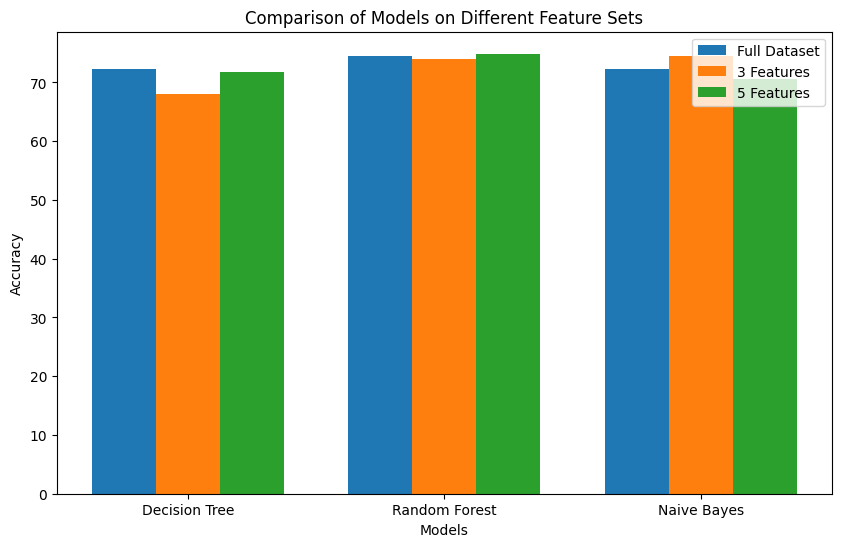

In [10]:
models = ['Decision Tree', 'Random Forest', 'Naive Bayes']

full_acc = full_results_df['Accuracy']

feature3_acc = results_3_df['Accuracy']

feature5_acc = results_5_df['Accuracy']

x = np.arange(len(models))

width = 0.25

plt.figure(figsize=(10,6))

# Full Dataset
plt.bar(
    x - width,
    full_acc,
    width,
    label='Full Dataset'
)

# 3 Features
plt.bar(
    x,
    feature3_acc,
    width,
    label='3 Features'
)

# 5 Features
plt.bar(
    x + width,
    feature5_acc,
    width,
    label='5 Features'
)

plt.xlabel("Models")

plt.ylabel("Accuracy")

plt.title("Comparison of Models on Different Feature Sets")

plt.xticks(x, models)

plt.legend()

plt.show()